Gradient Boosting Regressor

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor


In [2]:
data = pd.read_csv(
    "../data/cleaned_panel_data.csv",
    parse_dates=["Date"]
)

data = data.sort_values(["ticker", "Date"]).reset_index(drop=True)


In [3]:
data["log_return_1d"] = (
    data.groupby("ticker")["Close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

data["next_day_return"] = (
    data.groupby("ticker")["log_return_1d"]
    .shift(-1)
)


In [4]:
data["mom_5"] = (
    data.groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(5).sum())
)

data["mom_10"] = (
    data.groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(10).sum())
)

data["vol_5"] = (
    data.groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(5).std())
)

data["vol_10"] = (
    data.groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(10).std())
)


In [5]:
data = data.dropna().reset_index(drop=True)


In [6]:
features = ["mom_5", "mom_10", "vol_5", "vol_10"]
target = "next_day_return"


In [7]:
LOOKBACK = 252

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    random_state=42
)


In [8]:
data["predicted_return_gbdt"] = np.nan


In [9]:
unique_dates = np.sort(data["Date"].unique())

for i in range(LOOKBACK, len(unique_dates)):
    train_dates = unique_dates[i - LOOKBACK : i]
    test_date = unique_dates[i]
    
    train_data = data[data["Date"].isin(train_dates)]
    test_data = data[data["Date"] == test_date]
    
    X_train = train_data[features]
    y_train = train_data[target]
    X_test = test_data[features]
    
    gb_model.fit(X_train, y_train)
    
    data.loc[test_data.index, "predicted_return_gbdt"] = gb_model.predict(X_test)


In [10]:
data["predicted_return_gbdt"].notna().mean()


np.float64(0.8991995967983872)

In [11]:
data_gbdt = data.dropna(subset=["predicted_return_gbdt"]).reset_index(drop=True)


In [12]:
data_gbdt["pred_rank"] = (
    data_gbdt.groupby("Date")["predicted_return_gbdt"]
    .rank(ascending=False, method="first")
)


In [13]:
data_gbdt["n_assets"] = (
    data_gbdt.groupby("Date")["ticker"]
    .transform("count")
)


In [14]:
data_gbdt["is_long"] = data_gbdt["pred_rank"] <= 0.2 * data_gbdt["n_assets"]
data_gbdt["is_short"] = data_gbdt["pred_rank"] > 0.8 * data_gbdt["n_assets"]


In [15]:
data_gbdt["inv_vol"] = 1 / data_gbdt["vol_10"]


In [17]:
#lONG WEIGHTS
data_gbdt["long_weight"] = 0.0
long_mask = data_gbdt["is_long"]

data_gbdt.loc[long_mask, "long_weight"] = (
    data_gbdt.loc[long_mask, "inv_vol"] /
    data_gbdt.loc[long_mask].groupby("Date")["inv_vol"].transform("sum")
)


In [19]:
#SHORT WEIGHTS
data_gbdt["short_weight"] = 0.0
short_mask = data_gbdt["is_short"]

data_gbdt.loc[short_mask, "short_weight"] = (
    - data_gbdt.loc[short_mask, "inv_vol"] /
    data_gbdt.loc[short_mask].groupby("Date")["inv_vol"].transform("sum")
)


In [20]:
#FINAL POSITION WEIGHTS
data_gbdt["position_weight"] = (
    data_gbdt["long_weight"] + data_gbdt["short_weight"]
)


In [21]:
#PORTFOLIO RETURNS
portfolio_returns_gbdt = (
    data_gbdt.groupby("Date")
    .apply(lambda x: (x["position_weight"] * x["next_day_return"]).sum())
)


In [26]:
#CUMULATIVE PERFORMANCE
cum_log_return_gbdt = portfolio_returns_gbdt.cumsum()
cum_return_gbdt = np.exp(cum_log_return_gbdt)


In [29]:
market_returns = (
    data_gbdt.groupby("Date")["next_day_return"]
    .mean()
)


In [30]:
cum_market = np.exp(market_returns.cumsum())


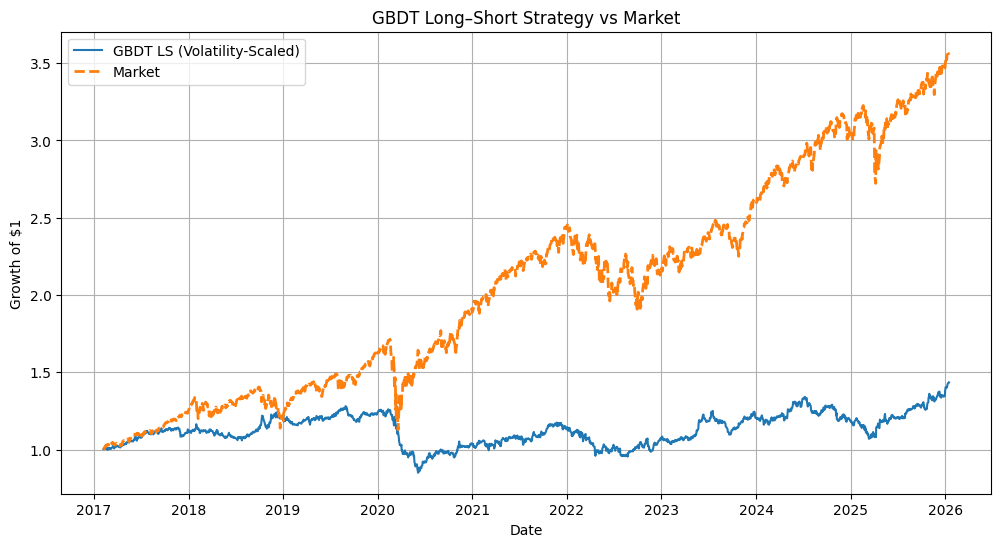

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(cum_return_gbdt, label="GBDT LS (Volatility-Scaled)")
plt.plot(cum_market, label="Market", linestyle="--", linewidth=2)

plt.title("GBDT Long–Short Strategy vs Market")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()


STRATEGY ENHANCEMENTS


In [41]:
print("Market start:", cum_market.index.min())
print("Market end:", cum_market.index.max())
print("Market final:", cum_market.iloc[-1])


Market start: 2017-02-07 00:00:00
Market end: 2026-01-15 00:00:00
Market final: 3.5590266285377
